# Drishti — Indian Currency Classifier

Trains the specialist model behind **Money mode**. A note is a closed-set classification
problem with six classes, so it does not need the VLM — a MobileNet is smaller, faster and
more accurate here, which is the routing principle the whole project rests on (`DEC-012`).

**Backbone: MobileNetV3-Small.** ~2.5M parameters, designed for phones, and the Phase-5
Android port is the reason to pick it now rather than a ResNet that would have to be
replaced later.

## The metric that matters is not accuracy

Misclassification cost here is **asymmetric in rupees**. Calling a ₹500 note a ₹100 costs
the user ₹400; calling a ₹10 a ₹20 costs ₹10. Plain accuracy treats those identically, so
this notebook also reports **expected rupee error per identification** and a confusion
matrix weighted by value.

## Abstention, again

Same principle as the VLM (`DEC-016`) and medicine mode (`DEC-007`): for a blind user a
confident wrong answer is worse than "I can't tell". The model must decline below a
confidence threshold, and §6 sweeps that threshold rather than assuming one.

---

### Before running

The corpus is assembled from **licence-clean public datasets** — there is no self-collected
photography (`DEC-047`). The setup cell below builds it: three Kaggle sources, plus VizWiz
photographs as "no note in frame" negatives, merged and deduplicated.

| Source | Licence | Kept |
|---|---|---|
| `vishalmane109/indian-currency-note-images-dataset-2020` | CC0-1.0 | 3,083 |
| `pypiahmad/indian-rupees-and-thai-baht-banknotes` | CC BY 4.0 · **attribution required** | 1,961 |
| VizWiz-VQA negatives | CC BY 4.0 · **attribution required** | 485 |
| `gauravsahani/indian-currency-notes-classifier` | DbCL-1.0 | 73 |
| ~~`shobhit18th/indian-currency-notes`~~ | unknown — **excluded** (`DEC-022`) | — |

**5,602 images across eight classes**, deduplicated by content hash and perceptual hash.
`gauravsahani` turned out to be almost entirely a re-host: 73 of roughly 200 images
survived, so without hashing they would have been added as if new.

`background/` is 883 photographs with **no note in frame**, most from VizWiz. It is a real
class, not junk: with only seven denominations available, a photo of a table must come back
as *some* amount, and money mode would speak it. `app/modes/currency.py` maps it to
reframing guidance instead (`DEC-039`).

**Why deduplication is not housekeeping.** The single-source corpus had 23% redundancy, and
33.5% of its test split were duplicates of training images. Accuracy barely moved, but
expected cost was understated by 54% (`DEC-049`). The leakage check after the split exists
so that can never pass unnoticed again.

**Read the rupee-weighted error, not the accuracy.** `background` is ~16% of the data, so a
model that learned nothing else scores 16%, and one that never predicts it still looks fine.
`class_value('background')` is ₹0, so calling a real ₹500 `background` scores as a ₹500
error when it is in truth the *cheap* failure — the user retakes the photo. The expensive
direction is calling an empty table ₹500. Report them separately.

Colab: `Runtime → T4 GPU`. Building the corpus downloads roughly 750 MB; training is about
35 minutes.


## 0. Setup — repo, dataset, paths

Run this first, on Colab or locally. It clones the repo when needed, fetches the dataset
from Kaggle and reshapes it into the folder-per-class layout `ImageFolder` requires.

**The 2.4 GB dataset is gitignored and is not in the repo.** Cloning gives you the code and
nothing to train on, which is why this cell downloads rather than assuming. It is also why
`git add .` should never be pointed at `data/currency`.

**Kaggle credentials — never type the token into a cell.** A token written into a notebook
is committed the moment you save it. Get one at kaggle.com → Settings → API → *Generate New
Token*, then supply it whichever way matches how you are running this:

| Running via | How |
|---|---|
| **Colab web UI** | Key icon in the left sidebar → secret named `KAGGLE_API_TOKEN` → switch on *Notebook access* |
| **Colab VS Code extension** | Nothing to set up — the cell prompts, with the input hidden |

Colab Secrets are **only** readable from the web UI. Through the VS Code extension
`userdata.get()` blocks and raises `TimeoutException`, the same browser-only limitation
that stops `files.upload()` working there (see notebook 04 §1). The setup cell tries the
secret first and falls back to a hidden prompt, so both paths work and neither stores the
token in this file.

Re-running is cheap: if `data/currency/` already has class folders, both steps are skipped.


In [13]:
# Environment setup. Runs the same on Colab and on a laptop; only the paths differ.
#
# The dataset is 2.4 GB and gitignored, so it does NOT arrive with the repo -- cloning on
# Colab gives you the code and nothing to train on. It is fetched from Kaggle here instead,
# which is also why it never needs to be pushed anywhere.
import os
import subprocess
import sys
from pathlib import Path

# (kaggle ref, local slug). The slug names the source directory, and merge_currency.py
# looks its licence up by that name -- a directory it does not recognise stops the merge
# rather than being assumed usable (DEC-022).
DATASETS = [
    ('vishalmane109/indian-currency-note-images-dataset-2020', 'vishalmane109'),  # CC0-1.0
    ('gauravsahani/indian-currency-notes-classifier', 'gauravsahani'),            # DbCL-1.0
    ('pypiahmad/indian-rupees-and-thai-baht-banknotes', 'pypiahmad'),             # CC BY 4.0
]
REPO_URL = 'https://github.com/DevGurav/Drishti.git'

# Denominations to leave out of the corpus entirely. See DEC-054.
EXCLUDE = ['2000']

ON_COLAB = 'google.colab' in sys.modules or Path('/content').is_dir()

if ON_COLAB:
    PROJECT = Path('/content/drishti')
    if not PROJECT.exists():
        subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, str(PROJECT)], check=True)
    else:
        subprocess.run(['git', '-C', str(PROJECT), 'pull', '--ff-only'], check=False)

    # Kaggle credentials, never typed into a cell -- a token written into a notebook is
    # committed the moment it is saved. Three sources, least friction first:
    #
    #   1. KAGGLE_API_TOKEN already exported (a re-run in the same session)
    #   2. Colab Secrets -- but ONLY from the Colab web UI. Through the VS Code extension
    #      userdata.get() blocks and then raises TimeoutException, which is how this cell
    #      first failed. Same family as files.upload() being browser-only (notebook 04).
    #   3. A hidden prompt, which works in both the web UI and VS Code and stores nothing.
    if not os.environ.get('KAGGLE_API_TOKEN'):
        token = ''
        try:
            from google.colab import userdata
            token = userdata.get('KAGGLE_API_TOKEN')
            print('credentials: Colab secret')
        except Exception as e:
            print(f'Colab secrets unavailable ({type(e).__name__}) -- '
                  f'falling back to a prompt.')
            print('Get a token at kaggle.com -> Settings -> API -> Generate New Token.')
            from getpass import getpass
            token = getpass('Kaggle API token (input hidden): ').strip()
            if token:
                print('credentials: prompt')
        if not token:
            raise RuntimeError(
                'No Kaggle token supplied, so the dataset cannot be fetched. Re-run this '
                'cell and paste the token when prompted, or export KAGGLE_API_TOKEN.'
            )
        os.environ['KAGGLE_API_TOKEN'] = token
else:
    PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

RAW_DIR = PROJECT / 'data' / 'currency_raw'
DATA_DIR = PROJECT / 'data' / 'currency'
MANIFEST = PROJECT / 'data' / 'currency_manifest.csv'
OUT_PATH = PROJECT / 'models' / 'currency_mobilenetv3.pt'
SCRIPTS = PROJECT / 'data' / 'scripts'


def run(script, *args):
    subprocess.run([sys.executable, str(SCRIPTS / script), *args], check=True)


# Rebuild only when the corpus is absent. The check looks for *denomination* folders
# rather than any subdirectory: a raw download nests everything under one wrapper folder,
# which would otherwise be read as a single class -- and a one-class model answers the
# same denomination every time, confidently.
organized = sorted(p.name for p in DATA_DIR.iterdir()
                   if p.is_dir() and p.name.isdigit()) if DATA_DIR.is_dir() else []
if organized:
    print(f'corpus already built: {DATA_DIR}\nclasses: {organized}')
else:
    if ON_COLAB:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'kaggle'], check=True)

    # One source is not enough. Trained on vishalmane109 alone, the model scored 0.9883 on
    # that dataset's own split and cleared the confidence threshold on only 3 of 5 real
    # handheld notes -- every training image is cropped tight to the note (DEC-043).
    # Independent datasets were shot by different contributors at different distances, so
    # merging them buys capture diversity without a camera (DEC-047).
    for ref, slug in DATASETS:
        run('download_currency.py', '--dataset', ref, '--out', str(RAW_DIR / slug))

    # "No note in frame" negatives. The Kaggle background class is 431 photos of tables
    # and hands from one session and does not generalise -- a medicine strip scores 50 at
    # 0.870, held back only by the threshold (DEC-042). VizWiz is photographs taken by
    # blind people of arbitrary objects: the right distribution, from the right people.
    run('download_vizwiz.py')
    run('sample_vizwiz_negatives.py', '-n', '500')

    # Deduplicates by content hash and perceptual hash, refuses a source with no recorded
    # licence, and refuses to guess a class from a folder name -- pypiahmad ships Thai
    # baht in folders like THAI20, which any digit rule would label as Rs 20.
    # Rs 2000 is excluded. It was withdrawn from circulation in May 2023, and the class
    # was doing more harm than good: it acted as an attractor, turning Rs 10 and Rs 20
    # notes into Rs 1,990 errors, and four Rs 2000-related mistakes carried 86% of all
    # rupee cost in the previous run (DEC-054). Pass EXCLUDE = [] to train on it again.
    run('merge_currency.py', '--clean', *(['--exclude', *EXCLUDE] if EXCLUDE else []))

print(f'\nproject : {PROJECT}')
print(f'data    : {DATA_DIR}')
print(f'manifest: {MANIFEST}')
print(f'model   : {OUT_PATH}')


corpus already built: /content/drishti/data/currency
classes: ['10', '100', '20', '200', '2000', '50', '500']

project : /content/drishti
data    : /content/drishti/data/currency
manifest: /content/drishti/data/currency_manifest.csv
model   : /content/drishti/models/currency_mobilenetv3.pt


In [14]:
%pip install -q torch torchvision scikit-learn matplotlib

import json, time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models, transforms

# DATA_DIR and OUT_PATH come from the setup cell above -- they differ between Colab
# (/content/drishti) and a laptop, and hardcoding '../' broke every Colab run.
assert 'DATA_DIR' in dir(), 'run the setup cell above first'

IMG_SIZE = 224
BATCH = 32
EPOCHS = 12
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

if not DATA_DIR.exists():
    raise SystemExit(
        f'{DATA_DIR} not found.\n'
        'Download a licensed Indian-currency dataset first:\n'
        '  python data/scripts/download_currency.py --dataset <owner>/<slug>\n'
        'then set DATA_DIR to the extracted folder.'
    )

device: cuda


## 1. Data and augmentation

Augmentation is chosen to match how a blind user actually photographs a note, not to pad
the dataset generically: notes arrive **folded, worn, partially in frame, at any rotation,
and under bad indoor light**. A model trained only on flat well-lit scans will score well
here and fail in the hand.

Horizontal flip is included (a note handed over upside-down is the same note); vertical
flip is too, for the same reason.

In [15]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.55, 1.0)),   # partially framed notes
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(25),                               # handheld tilt
    transforms.ColorJitter(brightness=0.45, contrast=0.35,
                           saturation=0.25, hue=0.03),           # indoor light, yellow bulbs
    transforms.RandomPerspective(distortion_scale=0.35, p=0.5),  # curved/folded notes
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.35, scale=(0.02, 0.18)),        # thumb over the note
])

eval_tf = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

full = datasets.ImageFolder(DATA_DIR)
CLASSES = full.classes
print(f'{len(full)} images across {len(CLASSES)} classes: {CLASSES}')

n_val = int(0.15 * len(full))
n_test = int(0.15 * len(full))
n_train = len(full) - n_val - n_test
gen = torch.Generator().manual_seed(SEED)
train_ds, val_ds, test_ds = random_split(full, [n_train, n_val, n_test], generator=gen)

# Subset shares the parent dataset, so transforms are attached per split via a wrapper.
class WithTransform(torch.utils.data.Dataset):
    def __init__(self, subset, tf):
        self.subset, self.tf = subset, tf
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, i):
        img, label = self.subset[i]
        return self.tf(img), label

train_dl = DataLoader(WithTransform(train_ds, train_tf), batch_size=BATCH, shuffle=True, num_workers=2)
val_dl = DataLoader(WithTransform(val_ds, eval_tf), batch_size=BATCH, num_workers=2)
test_dl = DataLoader(WithTransform(test_ds, eval_tf), batch_size=BATCH, num_workers=2)
print(f'train {n_train} · val {n_val} · test {n_test}')

5602 images across 8 classes: ['10', '100', '20', '200', '2000', '50', '500', 'background']
train 3922 · val 840 · test 840


### Is the split honest?

The previous run reported 0.9883 accuracy on a test split of which **33.5% was a duplicate
or near-duplicate of a training image** (`DEC-049`). The effect on accuracy was small — the
model does recognise notes — but expected cost was understated by 54%, ₹0.71 against ₹1.09,
and that is the number `DEC-022` exists to track.

Two different problems get measured here, and only the first is leakage:

- **Same class, train and test.** The model has already seen this image with this label, so
  the score is partly memory. This is what inflates a benchmark.
- **Different class.** Not leakage — the model saw those pixels labelled as something else,
  which hurts rather than helps. `pypiahmad` shot every denomination in one setup, so a
  64-bit perceptual hash keys on the background and matches across denominations at the
  same index. Those are genuinely different notes and must not be deduplicated away.

The corpus is deduplicated, so same-class leakage should be zero. It runs anyway, because
the failure is invisible: every filename distinct, every metric plausible, nothing to notice
unless you look. Hashes come from `data/currency_manifest.csv`, computed during the merge.

In [16]:
import csv
from pathlib import Path

# Hashes were computed during the merge; re-hashing 5,600 images here would be wasteful.
manifest = {}
if MANIFEST.exists():
    for row in csv.DictReader(MANIFEST.open(encoding='utf-8')):
        manifest[row['filename']] = (row['sha256'], int(row['dhash'], 16), row['class'])


def fingerprints(subset):
    out = []
    for i in subset.indices:
        name = Path(full.samples[i][0]).name
        if name in manifest:
            out.append(manifest[name])
    return out


if not manifest:
    print('No manifest -- corpus was not built by merge_currency.py, so leakage is '
          'unchecked.')
else:
    train_fp = fingerprints(train_ds)
    test_fp = fingerprints(test_ds)
    train_sha = {sha for sha, _, _ in train_fp}

    # Bucket by class: leakage means the model saw *this image with this label*.
    by_class = {}
    for _, d, cls in train_fp:
        by_class.setdefault(cls, []).append(d)

    exact = near = cross = 0
    for sha, d, cls in test_fp:
        if sha in train_sha:
            exact += 1
            continue
        if any(bin(d ^ t).count('1') <= 4 for t in by_class.get(cls, ())):
            near += 1
            continue
        if any(bin(d ^ t).count('1') <= 4
               for other, hashes in by_class.items() if other != cls
               for t in hashes):
            cross += 1

    leaked = exact + near
    n = max(len(test_fp), 1)
    print(f'LEAKAGE (same class, seen in training)')
    print(f'  identical      : {exact}')
    print(f'  near-identical : {near}')
    print(f'  total          : {leaked} of {len(test_fp)}  ({leaked / n:.1%})')
    print()
    print(f'cross-class look-alikes (not leakage): {cross}')
    print('  same shoot, different note -- these are hard negatives, keep them.')

    if leaked:
        print('\nThe numbers below are measured partly on images the model trained on.')
        print('Rebuild with:  python data/scripts/merge_currency.py --clean')
    else:
        print('\nSplit is clean.')


LEAKAGE (same class, seen in training)
  identical      : 0
  near-identical : 0
  total          : 0 of 840  (0.0%)

cross-class look-alikes (not leakage): 12
  same shoot, different note -- these are hard negatives, keep them.

Split is clean.


## 2. Model — MobileNetV3-Small, transfer learned

In [17]:
model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features, len(CLASSES))
model = model.to(DEVICE)

params = sum(p.numel() for p in model.parameters())
print(f'MobileNetV3-Small · {params/1e6:.2f}M parameters · {len(CLASSES)} classes')

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

MobileNetV3-Small · 1.53M parameters · 8 classes


In [18]:
def run_epoch(loader, train: bool):
    model.train(train)
    total_loss = correct = seen = 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            if train:
                optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            seen += y.size(0)
    return total_loss / seen, correct / seen


best_val, best_state = 0.0, None
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(train_dl, True)
    va_loss, va_acc = run_epoch(val_dl, False)
    scheduler.step()
    flag = ''
    if va_acc > best_val:
        best_val = va_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        flag = '  <- best'
    print(f'epoch {epoch:2d}  train {tr_acc:.3f}  val {va_acc:.3f}  '
          f'({time.time()-t0:.0f}s){flag}')

model.load_state_dict(best_state)
print(f'\nbest validation accuracy: {best_val:.4f}')

epoch  1  train 0.767  val 0.829  (189s)  <- best
epoch  2  train 0.905  val 0.933  (171s)  <- best
epoch  3  train 0.939  val 0.952  (170s)  <- best
epoch  4  train 0.945  val 0.964  (170s)  <- best
epoch  5  train 0.956  val 0.939  (172s)
epoch  6  train 0.965  val 0.973  (180s)  <- best
epoch  7  train 0.972  val 0.971  (173s)
epoch  8  train 0.978  val 0.983  (172s)  <- best
epoch  9  train 0.981  val 0.981  (171s)
epoch 10  train 0.986  val 0.987  (170s)  <- best
epoch 11  train 0.984  val 0.986  (169s)
epoch 12  train 0.984  val 0.986  (168s)

best validation accuracy: 0.9869


## 3. Test-set predictions

In [19]:
model.eval()
probs_all, y_all = [], []
with torch.no_grad():
    for x, y in test_dl:
        probs_all.append(torch.softmax(model(x.to(DEVICE)), dim=1).cpu())
        y_all.append(y)

probs = torch.cat(probs_all).numpy()
y_true = torch.cat(y_all).numpy()
y_pred = probs.argmax(1)
conf = probs.max(1)

acc = (y_pred == y_true).mean()
print(f'test accuracy: {acc:.4f}  (target >= 0.99)   n={len(y_true)}')

test accuracy: 0.9774  (target >= 0.99)   n=840


## 4. Rupee-weighted error

The project-specific metric. Two models with identical accuracy are not equally good if one
confuses ₹10 with ₹20 and the other confuses ₹100 with ₹500.

In [20]:
def class_value(name: str) -> float:
    """Rupee value from the folder name, tolerating '500', 'Rs500', '500_note'."""
    digits = ''.join(ch for ch in str(name) if ch.isdigit())
    return float(digits) if digits else 0.0

VALUES = np.array([class_value(c) for c in CLASSES])
print('class values:', dict(zip(CLASSES, VALUES)))

rupee_err = np.abs(VALUES[y_pred] - VALUES[y_true])
print(f'\nexpected rupee error per identification : Rs {rupee_err.mean():.2f}')
print(f'worst single error                      : Rs {rupee_err.max():.0f}')
print(f'errors costing more than Rs 100         : {(rupee_err > 100).sum()} of {len(y_true)}')

class values: {'10': np.float64(10.0), '100': np.float64(100.0), '20': np.float64(20.0), '200': np.float64(200.0), '2000': np.float64(2000.0), '50': np.float64(50.0), '500': np.float64(500.0), 'background': np.float64(0.0)}

expected rupee error per identification : Rs 9.43
worst single error                      : Rs 2000
errors costing more than Rs 100         : 9 of 840


              precision    recall  f1-score   support

          10      0.953     0.960     0.957       126
         100      0.983     0.991     0.987       117
          20      0.981     0.945     0.963       109
         200      0.959     0.986     0.973        72
        2000      0.989     0.978     0.983        90
          50      0.984     0.992     0.988       128
         500      0.984     0.984     0.984        62
  background      0.985     0.985     0.985       136

    accuracy                          0.977       840
   macro avg      0.977     0.978     0.977       840
weighted avg      0.977     0.977     0.977       840



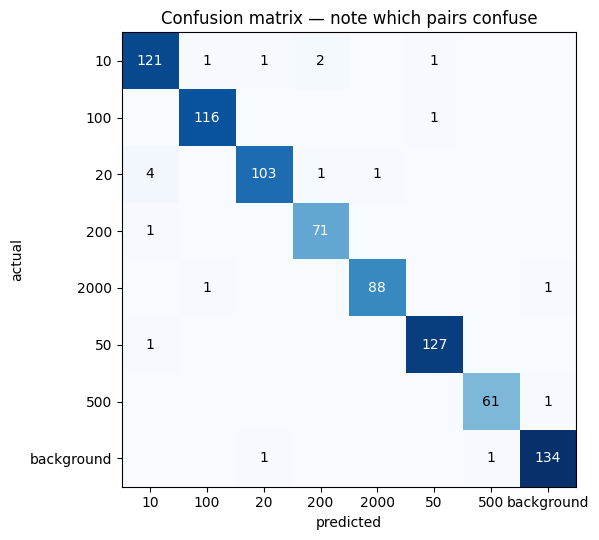


costliest confusions (by rupee impact):
  Rs   2000 total  ·  1 x  actual 2000 -> predicted background
  Rs   1980 total  ·  1 x  actual 20 -> predicted 2000
  Rs   1900 total  ·  1 x  actual 2000 -> predicted 100
  Rs    500 total  ·  1 x  actual background -> predicted 500
  Rs    500 total  ·  1 x  actual 500 -> predicted background
  Rs    380 total  ·  2 x  actual 10 -> predicted 200


In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASSES)), CLASSES)
ax.set_yticks(range(len(CLASSES)), CLASSES)
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title('Confusion matrix — note which pairs confuse')
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.tight_layout(); plt.show()

# The expensive confusions are the ones worth reporting, not the frequent ones.
print('\ncostliest confusions (by rupee impact):')
pairs = [(cm[i, j] * abs(VALUES[i] - VALUES[j]), CLASSES[i], CLASSES[j], cm[i, j])
         for i in range(len(CLASSES)) for j in range(len(CLASSES))
         if i != j and cm[i, j] > 0]
for cost, actual, pred, n in sorted(pairs, reverse=True)[:6]:
    print(f'  Rs {cost:6.0f} total  ·  {n} x  actual {actual} -> predicted {pred}')

## 5. Confidence threshold

`app/modes/currency.py` declines below a threshold rather than guessing. That constant was
set to 0.85 by assumption when the mode was scaffolded — this sweep replaces the assumption
with a measurement.

Read it the same way as the VLM abstention trade-off: a **refusal costs a retaken photo, a
wrong answer costs money.**

In [22]:
print(f"{'thresh':>7} {'answered':>9} {'acc|answered':>13} {'refused':>8} {'Rs err':>8}")
rows = []
for t in [0.0, 0.5, 0.7, 0.8, 0.85, 0.9, 0.95, 0.99]:
    keep = conf >= t
    if keep.sum() == 0:
        continue
    acc_k = (y_pred[keep] == y_true[keep]).mean()
    err_k = np.abs(VALUES[y_pred[keep]] - VALUES[y_true[keep]]).mean()
    rows.append((t, keep.mean(), acc_k, 1 - keep.mean(), err_k))
    print(f'{t:7.2f} {keep.mean():9.1%} {acc_k:13.4f} {1-keep.mean():8.1%} {err_k:8.2f}')

# Selection is by *rupee error*, not by the lowest threshold that scrapes past the bars.
#
# The first version of this cell took min(threshold) among viable rows, which on the
# 2026-08-10 run recommended 0.50 -- answering 98.7% of the time at Rs 1.32 expected error,
# when 0.90 answered 85% at Rs 0.71. Optimising for "answers often" contradicts DEC-022,
# which exists precisely because rupee cost, not answer rate, is what a wrong denomination
# costs the user. A refusal costs a retaken photo.
viable = [r for r in rows if r[2] >= 0.99 and r[1] >= 0.80]
if viable:
    best = min(viable, key=lambda r: (r[4], -r[1]))   # least rupee error, then most answers
    print(f'\nrecommended CONFIDENCE_THRESHOLD = {best[0]:.2f} '
          f'(answers {best[1]:.0%} of the time at {best[2]:.3f} accuracy, '
          f'Rs {best[4]:.2f} expected error)')
    cheapest = min(viable, key=lambda r: r[0])
    if cheapest[0] != best[0]:
        print(f'  (a lower bar of {cheapest[0]:.2f} would answer {cheapest[1]:.0%} of the '
              f'time but cost Rs {cheapest[4]:.2f} per identification)')
else:
    print('\nNo threshold reaches 99% while answering >=80% of the time.')
    print('Collect more data before shipping Money mode -- do not lower the bar.')

# Rows answering only a handful of samples are noise, not evidence. On the 2026-08-10 run
# the 0.99 row scored 0.9667 from 30 samples and one error, which reads as "a stricter
# threshold is worse" and is nothing of the kind.
thin = [r for r in rows if r[1] * len(y_true) < 50]
if thin:
    print('\nToo few answered to trust (n < 50): '
          + ', '.join(f'{r[0]:.2f}' for r in thin))

 thresh  answered  acc|answered  refused   Rs err
   0.00    100.0%        0.9774     0.0%     9.43
   0.50     99.2%        0.9820     0.8%     9.33
   0.70     97.9%        0.9866     2.1%     8.53
   0.80     95.6%        0.9913     4.4%     5.77
   0.85     93.5%        0.9924     6.5%     5.85
   0.90     89.6%        0.9947    10.4%     2.91
   0.95     67.0%        0.9964    33.0%     3.85
   0.99      4.2%        1.0000    95.8%     0.00

recommended CONFIDENCE_THRESHOLD = 0.90 (answers 90% of the time at 0.995 accuracy, Rs 2.91 expected error)
  (a lower bar of 0.80 would answer 96% of the time but cost Rs 5.77 per identification)

Too few answered to trust (n < 50): 0.99


## 6. Export

Class names and preprocessing travel **inside** the checkpoint. The app must never rely on
a hardcoded class order — a dataset with different folders would silently relabel every
prediction, and calling a ₹500 note ₹10 is exactly the failure this project cannot have.

In [23]:
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save({
    'state_dict': model.state_dict(),
    'arch': 'mobilenet_v3_small',
    'classes': CLASSES,
    'img_size': IMG_SIZE,
    'mean': IMAGENET_MEAN,
    'std': IMAGENET_STD,
    'test_accuracy': float(acc),
    'rupee_error': float(rupee_err.mean()),
    'trained': time.strftime('%Y-%m-%d'),
}, OUT_PATH)

print(f'saved {OUT_PATH}  ({OUT_PATH.stat().st_size/1e6:.1f} MB)')
print(f'test accuracy {acc:.4f} · rupee error Rs {rupee_err.mean():.2f}')
print('\nLoad it in the app with app/engines/currency_cnn.py::CurrencyClassifier')

saved /content/drishti/models/currency_mobilenetv3.pt  (6.2 MB)
test accuracy 0.9774 · rupee error Rs 9.43

Load it in the app with app/engines/currency_cnn.py::CurrencyClassifier


### Get the checkpoint off Colab — do not skip

`OUT_PATH` is on the **Colab runtime**, which is deleted when the session ends. Training
finishes, the numbers look good, and the model is gone with the VM. `models/` is also
gitignored (`*.pt`), so pushing is not the way it travels either.

Save it to the laptop that runs the demo, at exactly:

```
drishti/models/currency_mobilenetv3.pt
```

which is `DEFAULT_CHECKPOINT` in `app/engines/currency_cnn.py` — the app finds it with no
configuration. Everything the app needs is inside the file: class names, image size and
normalisation all travel with the weights, so nothing can silently relabel a prediction
(`DEC-023`).


In [24]:
# Download the checkpoint to your machine. It is ~6 MB.
#
# files.download() is a browser widget: it works in the Colab web UI and does nothing in
# the VS Code extension (same limitation as files.upload(), notebook 04 §1). The Drive
# fallback works in both, and also survives you closing the tab mid-download.
if ON_COLAB:
    try:
        from google.colab import files
        files.download(str(OUT_PATH))
        print(f'downloading {OUT_PATH.name} -- save it to drishti/models/')
    except Exception as e:
        print(f'Browser download unavailable ({type(e).__name__}). Use Drive instead:\n')
        print('    from google.colab import drive')
        print("    drive.mount('/content/drive')")
        print(f"    import shutil; shutil.copy('{OUT_PATH}', "
              f"'/content/drive/MyDrive/{OUT_PATH.name}')")
else:
    print(f'Already local: {OUT_PATH}')

print('\nVerify it loads before trusting the demo:')
print('    python -m app.cli --mode currency --image data/samples/some_note.jpg')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

downloading currency_mobilenetv3.pt -- save it to drishti/models/

Verify it loads before trusting the demo:
    python -m app.cli --mode currency --image data/samples/some_note.jpg


## Record for the report

1. Test accuracy against the ≥99% bar, **and** expected rupee error — the second is the
   metric that reflects what a wrong answer actually costs a user.
2. The costliest confusion pairs. If ₹100↔₹500 appears, say so and explain the mitigation
   (threshold, more data for that pair) rather than reporting only the headline accuracy.
3. The chosen `CONFIDENCE_THRESHOLD` and the refusal rate it implies. Update
   `app/modes/currency.py` and add a decision entry to `docs/BUILD_PLAN.md`.
4. Copy the checkpoint into `models/` (gitignored — record the numbers, not the weights).

**If accuracy is well below 99%,** the usual cause is a dataset of clean scans that does not
match handheld photos. Fix it with data, not by weakening the augmentation: shoot your own
notes under the conditions in `docs/data_collection_guide.md` and fine-tune on those.